In [1]:
import pandas as pd

In [2]:
arima = pd.read_csv("/content/arima_results.csv")
sarima = pd.read_csv("/content/sarima_results.csv")
xgb = pd.read_csv("/content/xgboost_results.csv")
lstm = pd.read_csv("/content/lstm_results.csv")


In [3]:
comparison = pd.concat(
    [arima, sarima, xgb, lstm],
    ignore_index=True
)

comparison

,Model,MAE,MSE,RMSE
0,ARIMA,4.674948,31.900165,5.648023
1,SARIMA,4.720057,32.408645,5.692859
2,XGBoost,4.485759,30.258917,5.500811
3,LSTM,4.701700,32.088138,5.664639


In [4]:
best = comparison.loc[
    comparison["RMSE"].idxmin()
]

print(best)

Model      XGBoost
MAE       4.485759
MSE      30.258917
RMSE      5.500811
Name: 2, dtype: object


In [5]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

In [6]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best, f)

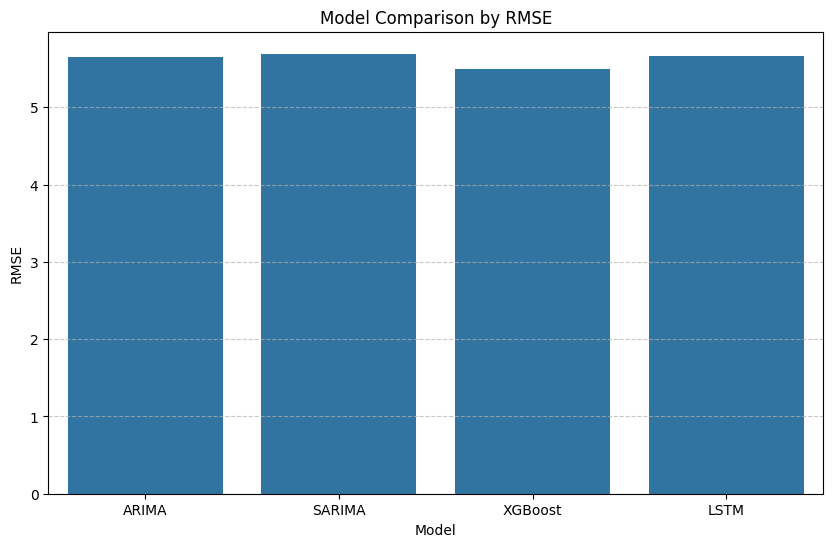

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSE', data=comparison)
plt.title('Model Comparison by RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

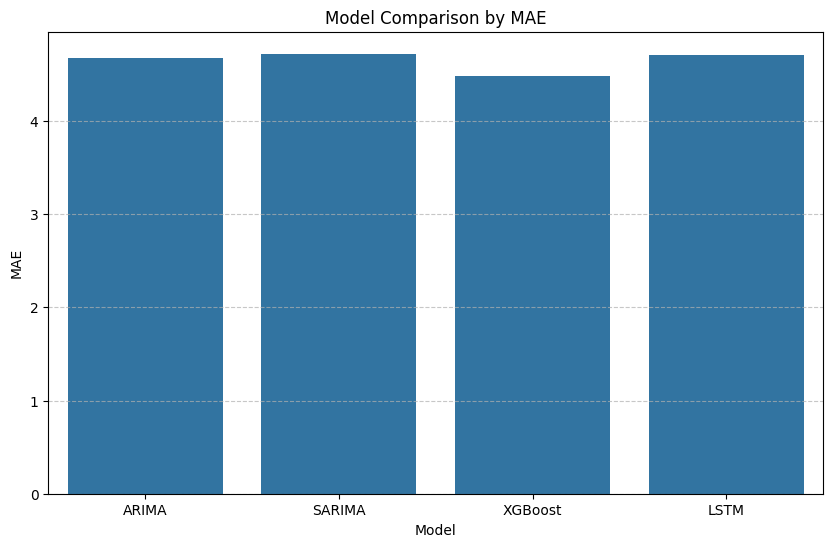

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MAE', data=comparison)
plt.title('Model Comparison by MAE')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

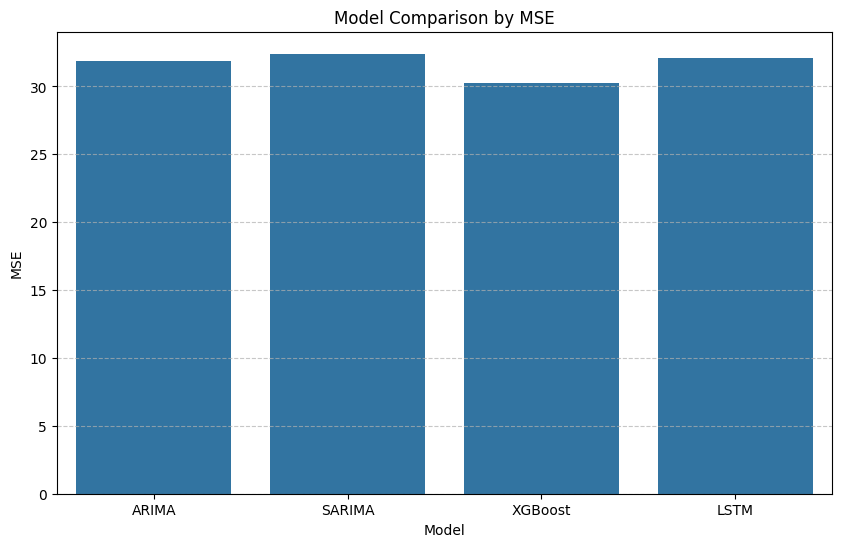

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MSE', data=comparison)
plt.title('Model Comparison by MSE')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
from google.colab import files

files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>